# Camada de decisão — de probabilidade a lista de campanha

## O que esta etapa resolve

A [modelagem](02_modelagem.ipynb) terminou com um modelo calibrado e uma frase que **ainda não é uma decisão**: *"lift de 2,89 no primeiro decil"*. Nenhum gerente de retenção sabe o que fazer com isso.

As perguntas reais são duas: **quantos clientes contatar** e **quais**. E nenhuma métrica estatística responde — nem F1, nem o ponto de Youden, nem o joelho da curva ROC. Todas escolhem um limiar sem nunca perguntar **quanto custa a oferta** nem **quanto vale o cliente**. São critérios que otimizam a forma da matriz de confusão, não o resultado do negócio.

Aqui o limiar sai de **valor esperado**. Como nas fases anteriores, este notebook **lê os artefatos** gravados por `python -m telco_churn.decisao` em vez de recalcular — assim texto e números não podem divergir.

> As decisões desta fase e suas razões estão em [Procedimentos e decisões da fase de modelagem](../docs/procedimentos-e-decisoes-da-fase-de-modelagem.md).

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

pd.set_option("display.width", 200)

raiz = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
figuras = raiz / "reports" / "figures"
d = json.loads((raiz / "models" / "decisao.json").read_text(encoding="utf-8"))

print("Parâmetros de negócio:")
for k, v in d["parametros"].items():
    print(f"  {k:18s} {v}")
print(f"\nBase de simulação: {d['n_base_simulacao']} clientes do conjunto de teste")

Parâmetros de negócio:
  margem             0.3
  desconto           0.1
  taxa_aceite        0.4
  horizonte_meses    12
  custo_contato      15.0

Base de simulação: 1409 clientes do conjunto de teste


## 1. O modelo econômico

Para um cliente com probabilidade de churn `p` e mensalidade `mc`, contatar tem três consequências:

| Componente | Quando ocorre | Valor |
|---|---|---|
| Margem preservada | Ele ia cancelar (`p`) **e** aceitou a oferta (`a`) | `p · a · margem · mc · H` |
| Custo de contato | Sempre que se aborda | `custo_contato` |
| Custo do desconto | Ele aceitou (`a`) — **tenha ou não** intenção de sair | `a · desconto · mc · H` |

$$VE = a \cdot mc \cdot H \cdot (p \cdot margem - desconto) - custo\_contato$$

**A terceira linha é a que a formulação ingênua omite, e é a mais importante.** A versão que se vê na maioria dos materiais é `VE = p × a × margem × H − custo_da_oferta`, que trata o desconto como se fosse pago apenas por clientes retidos. Não é: o desconto vai para **todo mundo que aceita**, inclusive para quem ia ficar de qualquer jeito. Esse é o custo real de qualquer campanha de retenção, e ignorá-lo infla o resultado.

Duas notas sobre as premissas:

- **`MonthlyCharges` entra como margem de contribuição, não receita.** Contar a mensalidade inteira como valor salvo superestimaria o ganho em mais de 3x — é o erro mais comum nesse tipo de conta.
- **Nenhum dos cinco parâmetros vem dos dados.** São premissas de negócio. É por isso que ficam num objeto próprio, entram no relatório e passam pela análise de sensibilidade da seção 5.

## 2. O piso: um limite que o modelo não consegue vencer

Isolando `p` na condição `VE > 0`:

$$p^* = \underbrace{\frac{desconto}{margem}}_{\text{piso}} + \underbrace{\frac{custo\_contato}{a \cdot margem \cdot mc \cdot H}}_{\text{termo por cliente}}$$

O primeiro termo **não depende do cliente, do horizonte, da taxa de aceite nem da qualidade do modelo**. Só da razão entre o desconto ofertado e a margem.

In [2]:
print(f"piso  = desconto/margem = {d['parametros']['desconto']} / {d['parametros']['margem']}"
      f" = {d['piso_do_limiar']:.3f}")
print(f"\nlimiar por cliente: mediana {d['limiar_mediano']:.3f}"
      f" | faixa {d['limiar_min']:.3f} a {d['limiar_max']:.3f}")

piso  = desconto/margem = 0.1 / 0.3 = 0.333

limiar por cliente: mediana 0.482 | faixa 0.423 a 0.904


In [3]:
sens = pd.DataFrame(d["sensibilidade"])
desconto = sens[sens["parametro"] == "desconto"].copy()

# .round(0) na tabela inteira zeraria as frações; cada coluna tem sua precisão
desconto.assign(
    desconto=desconto["valor"].map("{:.0%}".format),
    piso_do_limiar=desconto["piso_do_limiar"].map("{:.3f}".format),
    lucro_esperado=desconto["lucro_esperado"].map("R$ {:,.0f}".format),
)[["desconto", "piso_do_limiar", "n_contatados", "lucro_esperado"]].reset_index(drop=True)

,desconto,piso_do_limiar,n_contatados,lucro_esperado
0,2%,0.067,597,"R$ 21,301"
1,5%,0.167,487,"R$ 15,044"
2,10%,0.333,313,"R$ 7,223"
3,15%,0.500,154,"R$ 2,629"
4,20%,0.667,58,R$ 491
5,25%,0.833,0,R$ 0
6,30%,1.000,0,R$ 0


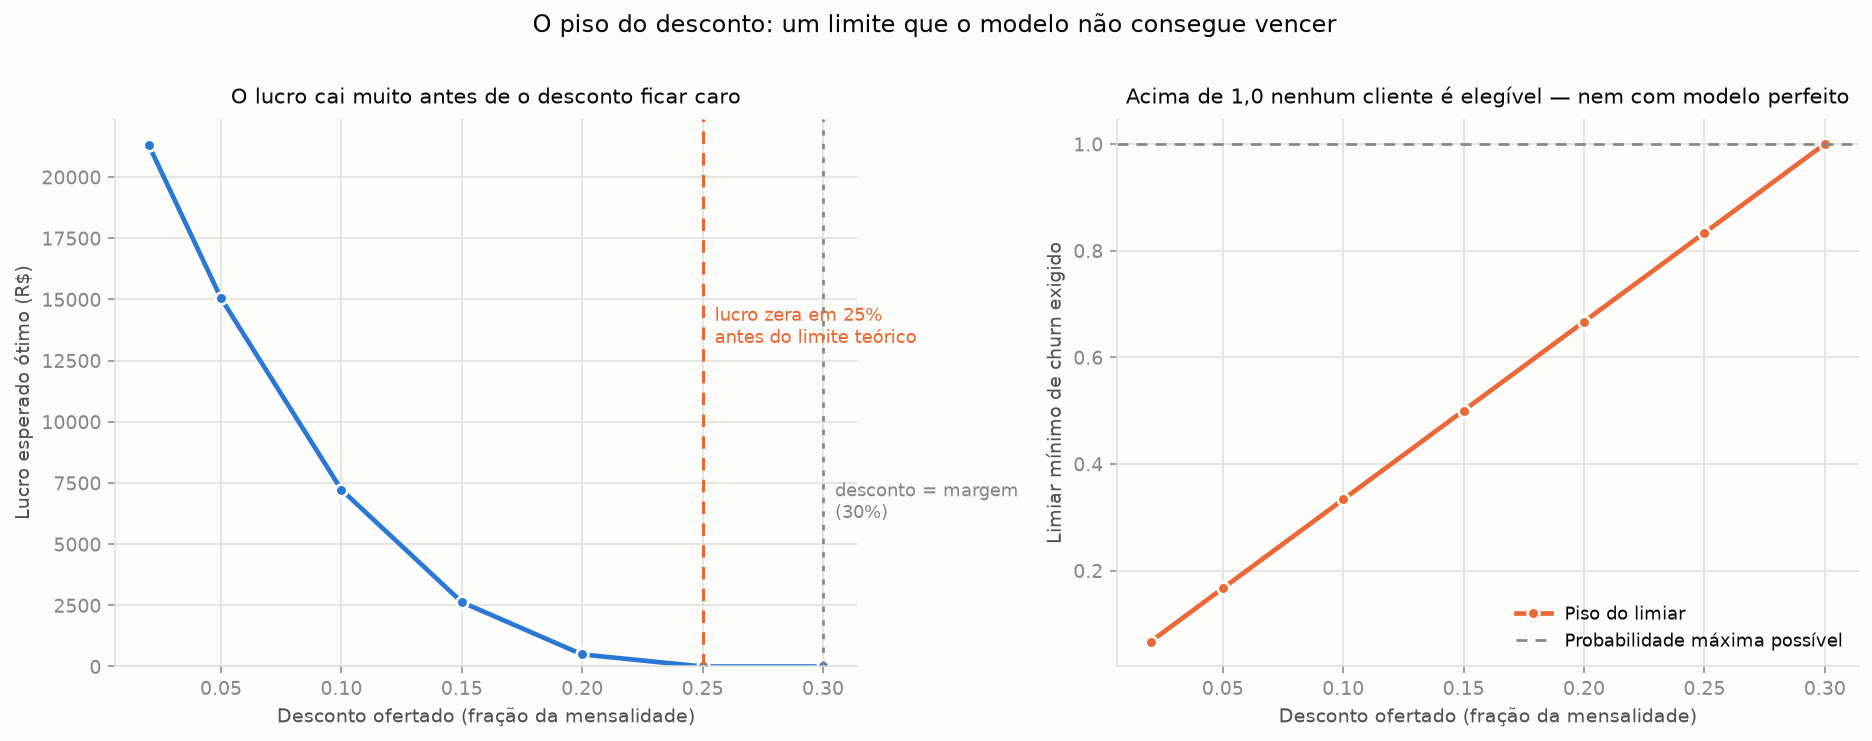

In [4]:
display(Image(filename=str(figuras / "piso_do_desconto.png")))

**Com desconto igual à margem, o piso vai a 1,0 e nenhum cliente jamais justifica contato** — por melhor que seja o modelo. Um ROC-AUC de 0,99 não salvaria a campanha, porque o problema não está na capacidade de prever: está no desenho da oferta. Cada real de desconto concedido a quem aceita precisa ser recuperado em margem de quem seria perdido, e se o desconto consome a margem inteira não sobra nada para recuperar.

Na prática ela morre **antes** disso. A tabela mostra lucro zero já em **25% de desconto**, com piso de 0,833: basta o piso ultrapassar a maior probabilidade que o modelo de fato produz para não sobrar ninguém elegível. O limite em `desconto = margem` é a garantia teórica; o limite real depende de quão alto o modelo consegue chegar, e chega antes.

Repare também na velocidade da queda no painel esquerdo. Entre 2% e 10% de desconto o lucro ótimo cai de ~R$ 21 mil para ~R$ 7 mil — **o resultado é muito mais sensível ao desenho da oferta do que a qualquer ganho de modelagem** que a Fase 3 pudesse ter arrancado.

Este é o tipo de conclusão que um projeto que para no AUC nunca alcança.

## 3. Não existe *um* limiar

O segundo termo da fórmula cai com a mensalidade. A consequência é que o corte é diferente para cada cliente: **cliente caro compensa ser abordado com muito menos certeza de que vai sair**, porque a margem em jogo é maior e o custo fixo de contato pesa proporcionalmente menos.

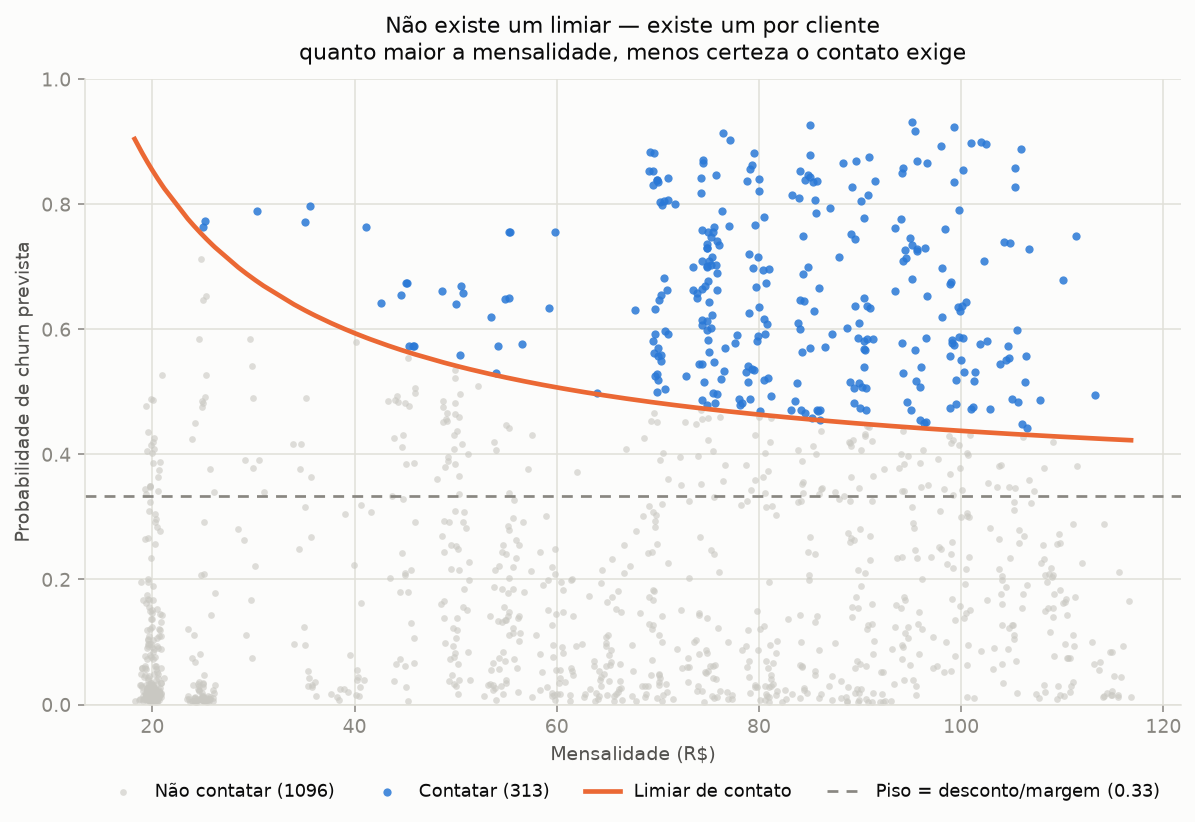

In [5]:
display(Image(filename=str(figuras / "limiar_por_cliente.png")))

A curva laranja é o limiar; os pontos azuis são quem entra na campanha. O limiar vai de **0,90 para um cliente de R$ 20** a **0,42 para um de R$ 118** — mais que o dobro de exigência para o cliente barato. A distância entre a curva e a linha tracejada é o termo por cliente; a linha tracejada é o piso, que nenhuma mensalidade vence.

Isso tem uma consequência operacional direta: **ordenar por valor esperado não é ordenar por probabilidade de churn**.

In [6]:
c = d["coincidencia_ve_vs_p"]
print(f"Entre os {c['corte']} primeiros de cada lista: {c['em_comum']} coincidem"
      f" ({c['em_comum'] / c['corte']:.0%})")
print(f"{c['trocam']} clientes trocam de lista — cerca de {c['trocam'] / c['corte']:.0%} da campanha")

Entre os 313 primeiros de cada lista: 286 coincidem (91%)
27 clientes trocam de lista — cerca de 9% da campanha


Os clientes que trocam são de dois tipos: os de mensalidade alta com risco moderado, que **entram** na lista por valor esperado embora não estivessem entre os de maior probabilidade; e os de mensalidade baixa com risco alto, que **saem**, porque a margem que preservam não cobre o custo de abordá-los.

## 4. Quantos contatar

O ponto ótimo é onde o valor esperado do próximo cliente da fila cruza o zero. Depois dele, cada contato adicional destrói valor — não porque o modelo piorou, mas porque a fila está ordenada e os que sobraram não pagam o próprio custo.

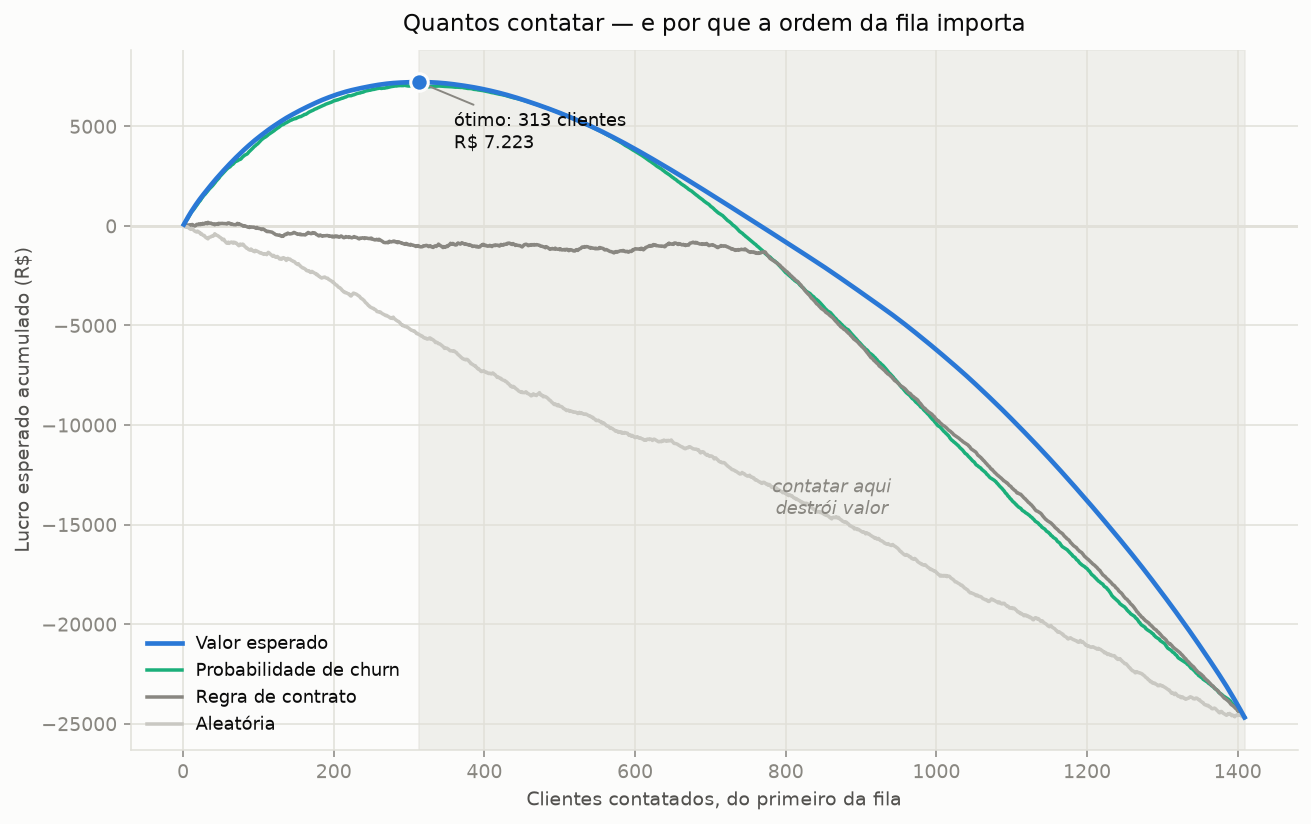

In [7]:
display(Image(filename=str(figuras / "curva_orcamento.png")))

In [8]:
otima = d["campanha_otima"]
print(f"Campanha ótima: {otima['n_contatados']} clientes"
      f" ({otima['fracao_da_base']:.1%} da base)")
print(f"  lucro esperado   R$ {otima['lucro_esperado']:>9,.0f}".replace(",", "."))
print(f"  por contato      R$ {otima['lucro_por_contato']:>9,.2f}")
print()
print("No mesmo orçamento, trocando apenas a ordem da fila:")
for nome, valor in d["lucro_no_orcamento_otimo"].items():
    print(f"  {nome:24s} R$ {valor:>9,.0f}".replace(",", "."))

Campanha ótima: 313 clientes (22.2% da base)
  lucro esperado   R$     7.223
  por contato      R$     23.08

No mesmo orçamento, trocando apenas a ordem da fila:
  Valor esperado           R$     7.223
  Probabilidade de churn   R$     7.017
  Regra de contrato        R$    -1.034
  Aleatória                R$    -5.453


As quatro linhas usam **exatamente a mesma conta de valor esperado**. O que muda é só quem entra na fila primeiro — e é isso que isola o que cada camada acrescenta:

- **Aleatória (R$ −5.453)** é o piso: contatar sem informação nenhuma destrói valor desde o primeiro cliente.
- **Regra de contrato (R$ −1.034)** é o que dá para fazer sem modelo. Repare que ela é **negativa**: mesmo acertando o segmento certo, contatar todos os clientes mês a mês inclui gente demais que não ia cancelar, e o desconto pago a eles come o ganho. Uma regra de uma linha identifica risco, mas não ordena dentro do grupo — e é a ordenação que a campanha precisa.
- **Probabilidade de churn (R$ 7.017)** é o que o modelo entrega sozinho.
- **Valor esperado (R$ 7.223)** é o que a camada de decisão acrescenta ao modelo: **+R$ 205**, ou ~2,9%.

Vale ser honesto sobre a magnitude: o ganho da camada de decisão sobre a simples ordenação por probabilidade é **pequeno**. As duas curvas quase se sobrepõem no gráfico. O salto grande é da regra de contrato para o modelo; da probabilidade para o valor esperado é um ajuste fino.

Mas há duas coisas que a ordenação por probabilidade **não** dá, e que são o real produto desta fase: ela não diz **onde parar** — sem a conta de valor esperado não existe ponto ótimo, apenas uma lista ordenada — e não diz **se a campanha deveria existir**, que é o resultado da seção 2.

Todas as quatro curvas convergem no extremo direito, como têm de convergir: contatando a base inteira, a ordem deixa de importar.

## 5. Sensibilidade: quais premissas dominam

Nenhum dos cinco parâmetros veio dos dados. Tratá-los como suposições, com faixa, é a única forma honesta de apresentar o resultado.

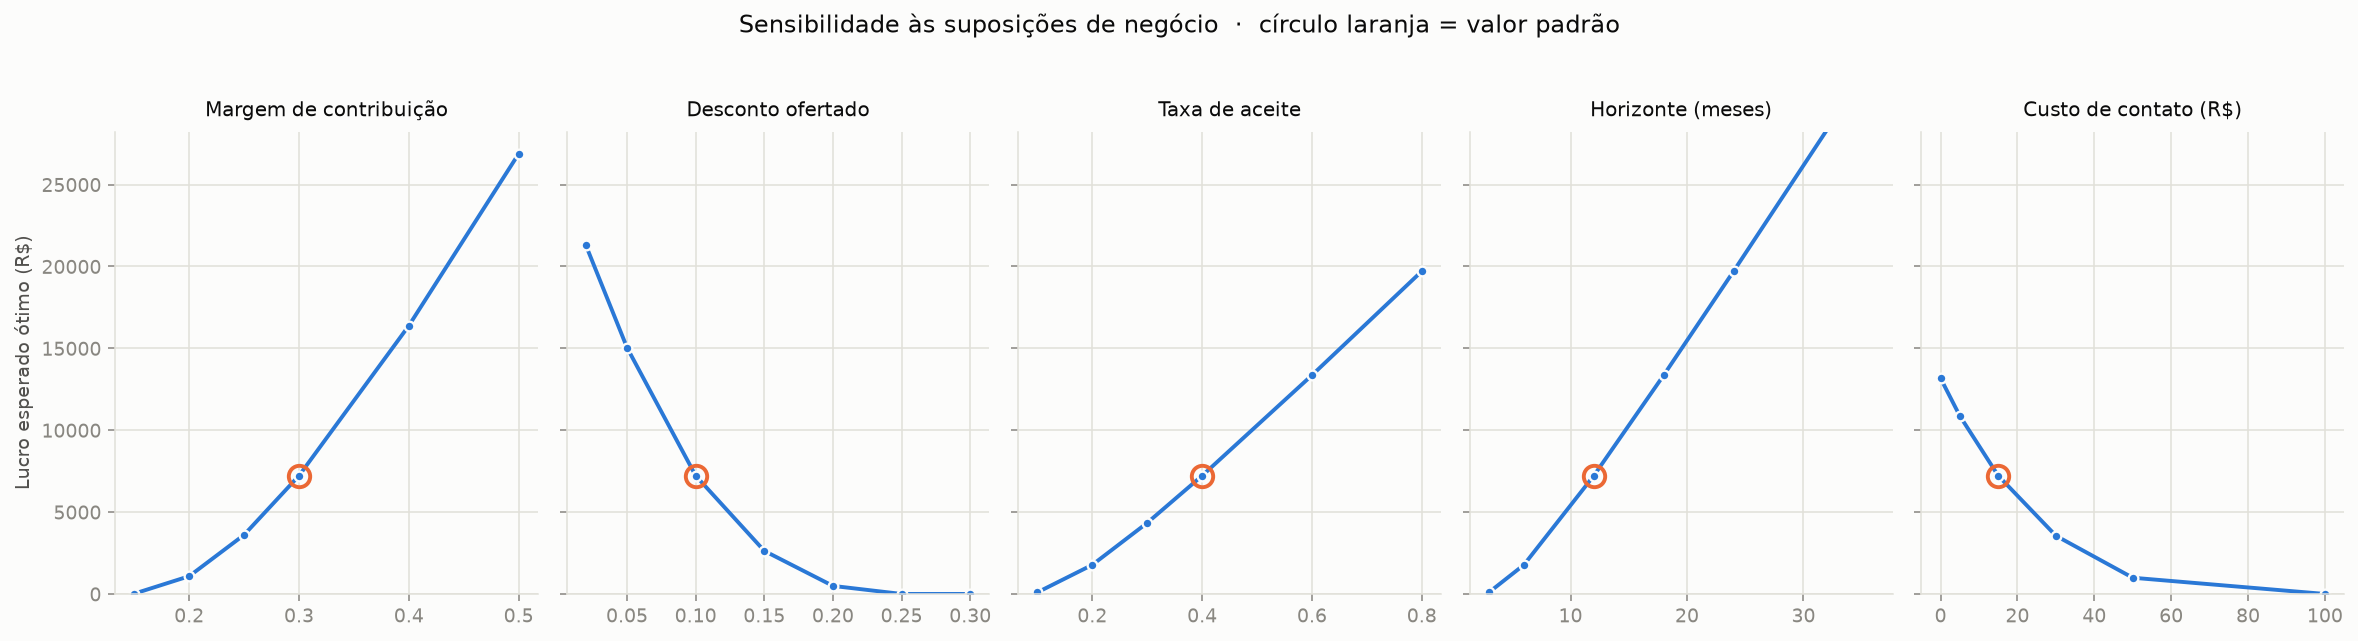

In [9]:
display(Image(filename=str(figuras / "sensibilidade.png")))

In [10]:
resumo = (sens.groupby("parametro")
          .agg(lucro_min=("lucro_esperado", "min"), lucro_max=("lucro_esperado", "max"),
               n_min=("n_contatados", "min"), n_max=("n_contatados", "max"))
          .assign(amplitude=lambda t: t["lucro_max"] - t["lucro_min"])
          .sort_values("amplitude", ascending=False))
resumo.round(0)

,lucro_min,lucro_max,n_min,n_max,amplitude
parametro,,,,,
horizonte_meses,97.0,32631.0,42,425,32534.0
margem,18.0,26881.0,9,514,26862.0
desconto,0.0,21301.0,0,597,21301.0
taxa_aceite,97.0,19709.0,42,394,19612.0
custo_contato,0.0,13172.0,0,504,13172.0


Os painéis compartilham o eixo vertical de propósito: com escalas independentes, todo parâmetro pareceria igualmente íngreme, e a pergunta do gráfico é justamente **qual deles domina**.

O **horizonte** e a **margem** têm a maior amplitude, mas os dois são características do negócio, não escolhas da campanha — não dá para decidir que a margem é 50%. Entre o que de fato se controla, o **desconto ofertado** é o mais decisivo, e no sentido contrário à intuição: reduzir o desconto de 10% para 5% dobra o lucro esperado, porque encolhe o subsídio pago a quem ia ficar.

A **taxa de aceite** é a premissa mais frágil de todas — não vem de dado nenhum, é palpite puro. É a primeira coisa que um piloto real mediria, e o motivo de ela ser um controle ajustável no dashboard em vez de uma constante enterrada no código.

## 6. Limitações

Estas não são rodapé. São o que separa uma análise de uma promessa.

**1. Não há modelo de uplift, e isso é o limite mais sério.**
O modelo prevê `P(churn)`, não `P(churn | não contatado) − P(churn | contatado)`. Uma campanha de retenção correta é dirigida pela **incrementalidade** — quem muda de comportamento por ter sido abordado —, não pelo risco. Os dois só coincidem se a oferta funcionar igualmente bem em todo mundo. Medir incrementalidade exige grupo de controle experimental, e esta base não tem nenhum: são 7.043 clientes observados, sem tratamento, sem aleatorização, sem histórico de campanha.

**2. Sleeping dogs.** Parte dos clientes cancela *porque* foi lembrada de que podia. O efeito é contrário ao que a campanha quer e é invisível sem experimento — contatar esses clientes é pior que não fazer nada.

**3. `taxa_aceite` é palpite.** Toda a magnitude do resultado escala com ela.

**4. Retenção não é permanente.** O horizonte é um corte arbitrário: nada impede o cliente retido de cancelar no mês seguinte ao fim do desconto. A conta assume que os `H` meses são preservados integralmente.

**5. `p` é probabilidade na janela do rótulo, não taxa de risco mensal.** Tratá-la como se valesse ao longo de `H` meses é aproximação.

**6. A performance do modelo já era otimista.** Sem split temporal (ver notebook 02), a estimativa de `p` é melhor do que seria em produção — e o lucro calculado herda esse otimismo.

**Como isso seria resolvido de verdade:** um piloto com grupo de controle aleatorizado, medindo aceite real e churn incremental nos dois braços. O resultado deste notebook é o que dimensiona esse piloto — quantos clientes, quais e qual retorno esperar —, não um número para levar ao comitê de orçamento.

## 7. Conclusões

**1. O desenho da oferta importa mais que o modelo.** O limiar tem um piso igual a `desconto/margem`, que nenhuma qualidade de modelo vence. Com desconto igual à margem, a campanha é impossível — e entre 2% e 10% de desconto o lucro ótimo cai de ~R$ 21 mil para ~R$ 7 mil.

**2. Não existe um limiar, existe um por cliente.** De 0,90 para um cliente de R$ 20 a 0,42 para um de R$ 118. Cerca de 9% da campanha muda de alvo em relação à ordenação por probabilidade.

**3. A resposta operacional.** Contatar os **313 clientes** de maior valor esperado (22% da base) rende **R$ 7.223** de lucro esperado, ou R$ 23,08 por contato. Contra **R$ −1.034** da regra de contrato no mesmo orçamento — que é *negativo*.

**4. O ganho da camada de decisão sobre a probabilidade pura é modesto** (+R$ 205, ~2,9%). O que ela acrescenta de fato não é ordenação melhor: é **saber onde parar** e **saber se a campanha deveria existir**.

**5. Sem uplift, tudo isto dimensiona um piloto — não autoriza uma campanha.**